In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [17]:
df = pd.read_csv(r"C:\eda_data\retail_sales_dataset.csv")

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [18]:
print("Dataset Shape (rows, columns):", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Dataset Shape (rows, columns): (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [19]:
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [20]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Total Sales by Product Category:
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


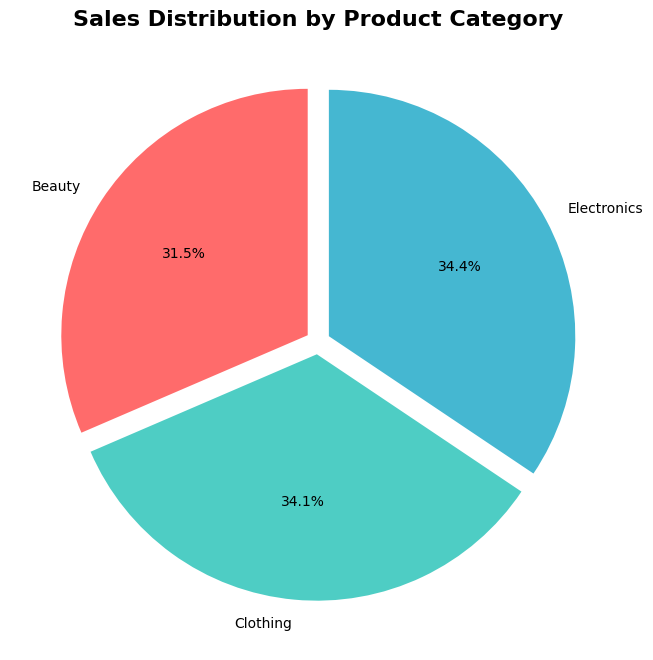

In [22]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Product Category')['Total Amount'].sum()

print("Total Sales by Product Category:")
print(category_sales)

plt.figure(figsize=(8, 8))
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=(0.05, 0.05, 0.05))
plt.title('Sales Distribution by Product Category', fontsize=16, fontweight='bold')
plt.show()

Total Sales by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


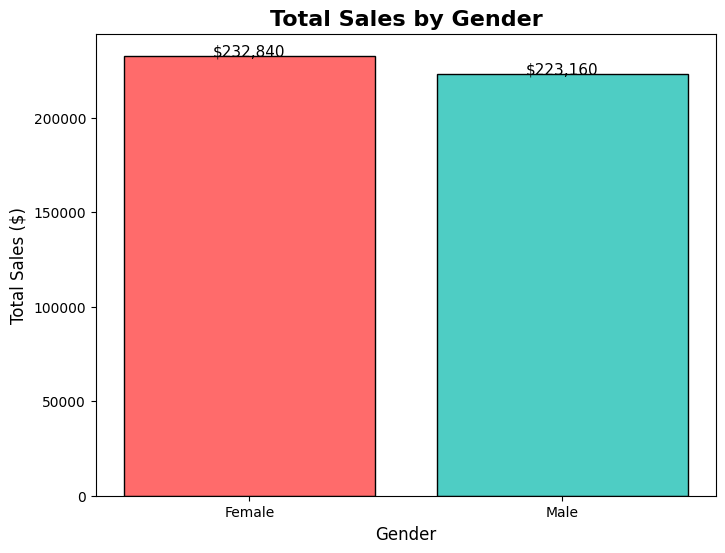

In [23]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

print("Total Sales by Gender:")
print(gender_sales)

plt.figure(figsize=(8, 6))
colors = ['#ff6b6b', '#4ecdc4']
plt.bar(gender_sales.index, gender_sales.values, color=colors, edgecolor='black')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.title('Total Sales by Gender', fontsize=16, fontweight='bold')

for i, value in enumerate(gender_sales.values):
    plt.text(i, value + 100, f'${value:,.0f}', ha='center', fontsize=11)

plt.show()

Total Sales by Age Group:
Age Group
<18       11215
18-24     73335
25-34     98480
35-44     91870
45-54    100690
55+       80410
Name: Total Amount, dtype: int64


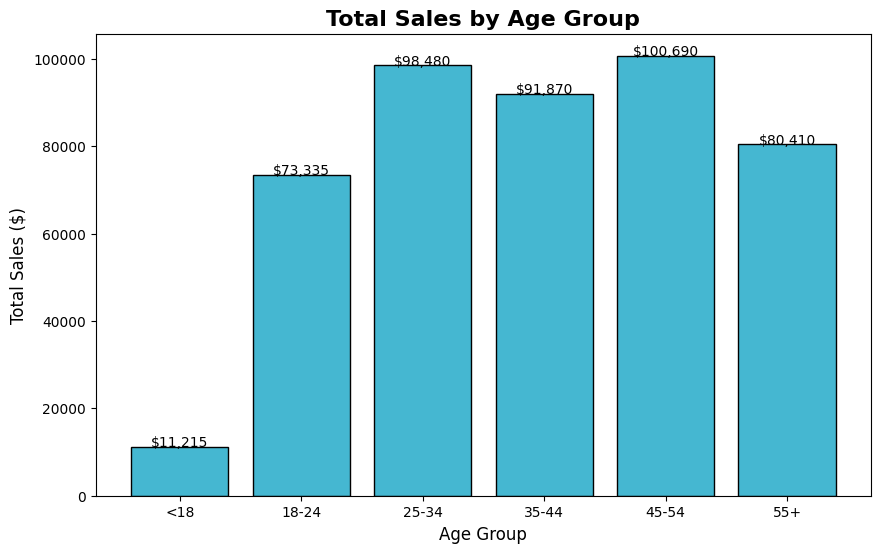

In [24]:
bins = [0, 18, 25, 35, 45, 55, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_sales = df.groupby('Age Group')['Total Amount'].sum()

print("Total Sales by Age Group:")
print(age_sales)

plt.figure(figsize=(10, 6))
plt.bar(age_sales.index, age_sales.values, color='#45b7d1', edgecolor='black')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.title('Total Sales by Age Group', fontsize=16, fontweight='bold')

for i, value in enumerate(age_sales.values):
    plt.text(i, value + 100, f'${value:,.0f}', ha='center', fontsize=10)

plt.show()

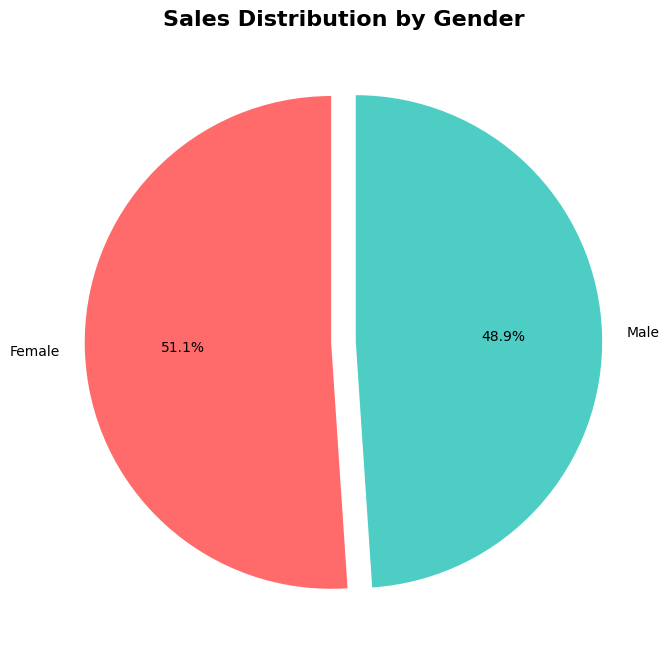

In [25]:
plt.figure(figsize=(8, 8))
colors = ['#ff6b6b', '#4ecdc4']
plt.pie(gender_sales, labels=gender_sales.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=(0.05, 0.05))
plt.title('Sales Distribution by Gender', fontsize=16, fontweight='bold')
plt.show()

In [26]:
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

print("="*50)
print("FINAL ANALYSIS REPORT")
print("="*50)

print("\n📊 Top Product Categories by Quantity Sold:")
for i, (product, qty) in enumerate(top_products.items(), 1):
    print(f"   {i}. {product}: {qty} units sold")

total_sales = df['Total Amount'].sum()
avg_transaction = df['Total Amount'].mean()
total_customers = df['Customer ID'].nunique()
avg_age = df['Age'].mean()

print("\n💰 KEY METRICS:")
print(f"   Total Revenue: ${total_sales:,.2f}")
print(f"   Average Transaction Value: ${avg_transaction:.2f}")
print(f"   Unique Customers: {total_customers}")
print(f"   Average Customer Age: {avg_age:.1f} years")

print("\n💡 BUSINESS RECOMMENDATIONS:")
print("   1. Focus marketing on highest-selling product categories")
print("   2. Target age groups with highest sales (check age group chart)")
print("   3. Consider loyalty program for frequent customers")
print("   4. Run promotions during low-sales periods")
print("   5. Expand product lines in top-performing categories")

FINAL ANALYSIS REPORT

📊 Top Product Categories by Quantity Sold:
   1. Clothing: 894 units sold
   2. Electronics: 849 units sold
   3. Beauty: 771 units sold

💰 KEY METRICS:
   Total Revenue: $456,000.00
   Average Transaction Value: $456.00
   Unique Customers: 1000
   Average Customer Age: 41.4 years

💡 BUSINESS RECOMMENDATIONS:
   1. Focus marketing on highest-selling product categories
   2. Target age groups with highest sales (check age group chart)
   3. Consider loyalty program for frequent customers
   4. Run promotions during low-sales periods
   5. Expand product lines in top-performing categories
